# Refined End-to-End Preferred API Workflow

This notebook mirrors the robust refined end-to-end smoke test using the newer preferred vector-builder API.

It writes real geopackage inputs on the fly, builds an optimized refined `TriangleGrid -> VoronoiGridPlus` mesh, and then assembles a single two-period MF6 model using:

- `CHDFromVector`
- `GHBFromVector`
- `DRNFromVector`
- `RCHFromVector`
- `KFromVector`
- `UZFPackageData`
- `LAK`
- `SFR`
- `MVR`

The surface-water coupling is deliberately mild so the single refined model stays stable while still attaching `SFR`, `LAK`, and `MVR` on the same grid.

In [1]:
from pathlib import Path
import shutil

import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.geometry import LineString, Point, box

import simple_modflow as mf
from simple_modflow.modflow.mf6.chd import CHDFromVector
from simple_modflow.modflow.mf6.drn import DRNFromVector
from simple_modflow.modflow.mf6.ghb import GHBFromVector
from simple_modflow.modflow.mf6.kflow import KFromVector
from simple_modflow.modflow.mf6.lakes import LakeConnectionData, LakePackageData, LakePeriodData
from simple_modflow.modflow.mf6.recharge import RCHFromVector
from simple_modflow.modflow.mf6.sfr import SFR
from simple_modflow.modflow.mf6.uzf import UZFPackageData
from simple_modflow.modflow.mf6.simulation.discretization import DisvGrid, TemporalDiscretization
from simple_modflow.modflow.mf6.simulation.packages import (
    CHD,
    InitialConditions,
    KFlow,
    LAK as LAKPackage,
    MVR,
    OutputControl,
    Recharge,
    Storage,
)


In [2]:
if Path.cwd().name == "notebooks" and Path.cwd().parent.name == "mf6":
    examples_root = Path.cwd().parent
else:
    examples_root = Path.cwd() / "examples" / "mf6"

workspace = examples_root / "artifacts" / "refined_end_to_end_preferred_api_workflow"
if workspace.exists():
    shutil.rmtree(workspace, ignore_errors=True)
workspace.mkdir(parents=True, exist_ok=True)

workspace

WindowsPath('c:/Users/lukem/Python/Projects/simple_modflow/examples/mf6/artifacts/refined_end_to_end_preferred_api_workflow')

In [3]:
def write_gpkg(path: Path, gdf: gpd.GeoDataFrame) -> Path:
    gdf.to_file(path, driver="GPKG")
    return path


def write_refined_workflow_vectors(workspace: Path) -> dict[str, object]:
    crs = "EPSG:2927"
    domain_geom = box(0.0, 0.0, 5000.0, 4000.0)
    west_band = box(0.0, 0.0, 225.0, 4000.0)
    east_band = box(4775.0, 0.0, 5000.0, 4000.0)
    north_band = box(0.0, 3650.0, 5000.0, 4000.0)

    stream_main = LineString([
        (250.0, 3500.0), (1200.0, 3050.0), (2300.0, 2400.0), (3550.0, 1650.0), (4750.0, 850.0)
    ])
    stream_branch = LineString([
        (650.0, 950.0), (1500.0, 1400.0), (2500.0, 1900.0), (3650.0, 2250.0), (4550.0, 2500.0)
    ])
    lake_west = Point(1650.0, 2550.0).buffer(290.0, quad_segs=24)
    lake_east = Point(3350.0, 1500.0).buffer(250.0, quad_segs=24)
    recharge_west = box(350.0, 2200.0, 2200.0, 3800.0)
    recharge_central = box(1850.0, 900.0, 3400.0, 2500.0)
    recharge_east = box(3100.0, 1300.0, 4700.0, 3400.0)
    k_west = box(0.0, 0.0, 2100.0, 4000.0)
    k_central = box(1650.0, 700.0, 3450.0, 3200.0)
    k_east = box(2900.0, 0.0, 5000.0, 4000.0)

    domain_path = write_gpkg(workspace / "refined_domain.gpkg", gpd.GeoDataFrame({"name": ["domain"]}, geometry=[domain_geom], crs=crs))
    stream_paths = [
        write_gpkg(workspace / "stream_main.gpkg", gpd.GeoDataFrame({"name": ["stream_main"]}, geometry=[stream_main], crs=crs)),
        write_gpkg(workspace / "stream_branch.gpkg", gpd.GeoDataFrame({"name": ["stream_branch"]}, geometry=[stream_branch], crs=crs)),
    ]
    lake_paths = [
        write_gpkg(workspace / "lake_west.gpkg", gpd.GeoDataFrame({"name": ["lake_west"]}, geometry=[lake_west], crs=crs)),
        write_gpkg(workspace / "lake_east.gpkg", gpd.GeoDataFrame({"name": ["lake_east"]}, geometry=[lake_east], crs=crs)),
    ]
    chd_path = write_gpkg(workspace / "boundary_chd.gpkg", gpd.GeoDataFrame({"name": ["west_chd"], "elev": [0.0], "layer": [1]}, geometry=[west_band], crs=crs))
    ghb_path = write_gpkg(
        workspace / "boundary_ghb.gpkg",
        gpd.GeoDataFrame({"name": ["east_ghb"], "elev": [0.0], "height": [0.0], "cond": [20.0], "layer": [1], "min_elev": [0.0]}, geometry=[east_band], crs=crs),
    )
    drn_path = write_gpkg(
        workspace / "boundary_drn.gpkg",
        gpd.GeoDataFrame({"name": ["north_drn"], "height": [-1.0], "cond": [5.0], "layer": [1], "min_elev": [0.0]}, geometry=[north_band], crs=crs),
    )
    rch_path = write_gpkg(
        workspace / "recharge_zones.gpkg",
        gpd.GeoDataFrame(
            {
                "zone": ["west_uplands", "central_infiltration", "east_uplands"],
                "rch_0": [0.00005, 0.00008, 0.00004],
                "rch_1": [0.00008, 0.00012, 0.00006],
            },
            geometry=[recharge_west, recharge_central, recharge_east],
            crs=crs,
        ),
    )
    k_path = write_gpkg(
        workspace / "k_zones.gpkg",
        gpd.GeoDataFrame({"name": ["west_k", "central_k", "east_k"], "k": [22.0, 12.0, 16.0], "layer": [1, 1, 1]}, geometry=[k_west, k_central, k_east], crs=crs),
    )
    refinement_paths = [
        write_gpkg(workspace / "refine_recharge_west.gpkg", gpd.GeoDataFrame({"name": ["west_uplands"]}, geometry=[recharge_west], crs=crs)),
        write_gpkg(workspace / "refine_recharge_central.gpkg", gpd.GeoDataFrame({"name": ["central_infiltration"]}, geometry=[recharge_central], crs=crs)),
        write_gpkg(workspace / "refine_recharge_east.gpkg", gpd.GeoDataFrame({"name": ["east_uplands"]}, geometry=[recharge_east], crs=crs)),
    ]
    return {
        "crs": crs,
        "domain": domain_path,
        "streams": stream_paths,
        "lakes": lake_paths,
        "chd": chd_path,
        "ghb": ghb_path,
        "drn": drn_path,
        "rch": rch_path,
        "k": k_path,
        "refinement_regions": refinement_paths,
    }


def build_refined_triangle(workspace: Path):
    inputs = write_refined_workflow_vectors(workspace)
    tri = mf.TriangleGrid(model_ws=str(workspace / "refined_mesh"), angle=30)
    tri.set_domain_file(inputs["domain"], simplify_tolerance=5, densify_dist=125, max_area=20000, label="domain")
    for stream_path, label in zip(inputs["streams"], ["stream_main", "stream_branch"], strict=True):
        tri.add_line_feature(stream_path, buffer=55, simplify_tolerance=5, densify_dist=75, max_area=3000, label=label, priority=5)
    for lake_path, label in zip(inputs["lakes"], ["lake_west", "lake_east"], strict=True):
        tri.add_region_file(lake_path, simplify_tolerance=5, densify_dist=50, max_area=2500, label=label, priority=6)
    for idx, refinement_path in enumerate(inputs["refinement_regions"]):
        tri.add_region_file(refinement_path, simplify_tolerance=5, densify_dist=80, max_area=5500, label=f"refine_zone_{idx}", priority=4)
    tri.add_region_polygon(box(900.0, 900.0, 4100.0, 3200.0), densify_dist=100, max_area=10000, label="interior_refinement", priority=3)
    mesh_report = tri.build_mesh(
        profile="balanced",
        protect_sources=("line",),
        protected_labels=["stream_main", "stream_branch", "lake_west", "lake_east"],
        target_segment_length=100,
        optimization_iterations=1,
        verbose=False,
    )
    vor = mf.VoronoiGridPlus(tri, crs=inputs["crs"], name="refined_vector_test")
    return tri, vor, mesh_report, inputs


tri, vor, mesh_report, inputs = build_refined_triangle(workspace)
vor.ncpl

Imported 1 features from c:\Users\lukem\Python\Projects\simple_modflow\examples\mf6\artifacts\refined_end_to_end_preferred_api_workflow\refined_domain.gpkg
Imported 1 features from c:\Users\lukem\Python\Projects\simple_modflow\examples\mf6\artifacts\refined_end_to_end_preferred_api_workflow\stream_main.gpkg
Imported 1 features from c:\Users\lukem\Python\Projects\simple_modflow\examples\mf6\artifacts\refined_end_to_end_preferred_api_workflow\stream_branch.gpkg
Imported 1 features from c:\Users\lukem\Python\Projects\simple_modflow\examples\mf6\artifacts\refined_end_to_end_preferred_api_workflow\lake_west.gpkg
Imported 1 features from c:\Users\lukem\Python\Projects\simple_modflow\examples\mf6\artifacts\refined_end_to_end_preferred_api_workflow\lake_east.gpkg
Imported 1 features from c:\Users\lukem\Python\Projects\simple_modflow\examples\mf6\artifacts\refined_end_to_end_preferred_api_workflow\refine_recharge_west.gpkg
Imported 1 features from c:\Users\lukem\Python\Projects\simple_modflow\e

4978

In [4]:
tri.preview_regions()[["label", "max_area", "claim_area", "priority"]]

,label,max_area,claim_area,priority
0,lake_east,2500,1.897184e+05,6
1,lake_west,2500,2.612360e+05,6
2,stream_branch,3000,4.656078e+05,5
3,stream_main,3000,2.148078e+05,5
4,refine_zone_1,5500,1.306153e+06,4
5,refine_zone_0,5500,2.697980e+06,4
6,refine_zone_2,5500,2.761080e+06,4
7,interior_refinement,10000,2.018120e+06,3
8,domain_size,20000,8.829405e+06,-10


In [5]:
vor.plot2d()

In [6]:
centroids = vor.gdf_vorPolys.geometry.centroid
top = 142.0 - (centroids.x.to_numpy() / 150.0) - (centroids.y.to_numpy() / 500.0)
bottom = top - 75.0 - 4.0 * np.sin(centroids.x.to_numpy() / 850.0)
bottom = np.minimum(bottom, top - 5.0)
vor.gdf_topbtm = gpd.GeoDataFrame(
    {"geometry": vor.gdf_vorPolys.geometry, 0: top, 1: bottom},
    geometry="geometry",
    crs=vor.crs,
)

top_arr = np.asarray(top, dtype=float)
bottom_arr = np.asarray(bottom, dtype=float)
initial_heads = np.maximum(bottom_arr + 10.0, top_arr - 8.0).tolist()

model = mf.SimulationBase(name="refined_e2e", mf_folder_path=workspace, vor=vor, nper=2)
DisvGrid(vor=vor, model=model, top=top.tolist(), bottom=[bottom.tolist()], nlay=1, idomain=[[1] * vor.ncpl])
TemporalDiscretization(model=model, period_data=[[1.0, 1, 1.0], [1.0, 1, 1.0]])
InitialConditions(model=model, vor=vor, nlay=1, strt=initial_heads)

k_builder = KFromVector(model=model, vor=vor, shp_gpkg=inputs["k"], uid="name")
k_array = k_builder.from_vector(defaults=[18.0])
KFlow(model=model, k=k_array[0].tolist(), k33_vert=(k_array[0] * 0.2).tolist(), save_specific_discharge=False)
Storage(model=model, sto_steady={0: True}, sto_transient={1: True})
OutputControl(model=model)

west_stage = float(np.nanpercentile(top_arr, 92) - 5.0)
east_stage = west_stage - 20.0

chd_builder = CHDFromVector(model=model, vor=vor, shp_gpkg=inputs["chd"], uid="name")
chd_dict = chd_builder.from_vector(head_reference={"west_chd": [west_stage, west_stage]}, register_regions=True, region_name_prefix="chd_group", combined_region_name="all_chd", overwrite_regions=True)
CHD(model=model, stress_period_data=chd_dict)

ghb_builder = GHBFromVector(model=model, vor=vor, shp_gpkg=inputs["ghb"], uid="name")
ghb_dict = ghb_builder.from_vector(elev_reference={"east_ghb": [east_stage, east_stage - 0.5]}, register_regions=True, region_name_prefix="ghb_group", combined_region_name="all_ghb", overwrite_regions=True)
mf.modflow.mf6.simulation.packages.GHB(model=model, stress_period_data=ghb_dict)

drn_builder = DRNFromVector(model=model, vor=vor, shp_gpkg=inputs["drn"], uid="name")
drn_dict = drn_builder.from_vector(edges_only=False, top_drain=True, register_regions=True, region_name_prefix="drn_group", combined_region_name="all_drains", overwrite_regions=True)
mf.modflow.mf6.simulation.packages.Drains(model=model, stress_period_data=drn_dict)

recharge_builder = RCHFromVector(model=model, vor=vor, shp_gpkg=inputs["rch"], uid="zone", rch_fields=["rch_0", "rch_1"], rch_fields_to_pers=[0, 1], background_rch=0.0, grid_type="disv", limit_to_k33=False)
rch_dict = recharge_builder.from_vector(register_regions=True, region_name_prefix="rch_zone", combined_region_name="all_rch", overwrite_regions=True)
Recharge(model=model, vor=vor, rch_dict=rch_dict)

uzf = UZFPackageData(model=model, vor=vor, vks=0.05, thtr=0.08, thts=0.28, thti=0.18, rch_from_shp=recharge_builder, add_uzf=True, register_regions=True, region_name="uzf_all", overwrite_regions=True)

lake_connections = LakeConnectionData(model=model, vor=vor, paths=[inputs["lakes"][0]], bed_leakance=0.001, horizontal_connections={0: [126.0, 118.0]}, use_reconciled_surfaces=False, only_vertical=True, register_regions=True, region_name_prefix="lake_zone", combined_region_name="all_lakes", region_tags=["lak"], overwrite_regions=True)
connectiondata = lake_connections.connection_data
lake_packagedata = LakePackageData(nlakes=1, starting_stage=[129.0], connectiondata=connectiondata)
lake_perioddata = LakePeriodData(model=model, lake_ids=[0], lake_stages=[129.0, 129.0], status=["ACTIVE", "ACTIVE"])
LAKPackage(model=model, nlakes=1, noutlets=0, ntables=0, packagedata=lake_packagedata.packagedata, connectiondata=connectiondata, perioddata=lake_perioddata.perioddata, mover=True)

sfr = SFR(model=model, vor=vor, stream_paths=[inputs["streams"][0]], inflows={0: [(0, 0.005)], 1: [(0, 0.005)]}, widths=5.0, gradients=0.0008, mannings=0.03, streambed_k=0.05, streambed_thickness=2.0, mover=True, add_sfr=True, register_regions=True, region_name_prefix="sfr_group", combined_region_name="all_streams", overwrite_regions=True)

mvr_perioddata = {
    0: [["sfr", sfr.stream_reaches[0][-1] - 1, "lak", 0, "FACTOR", 0.25]],
    1: [["sfr", sfr.stream_reaches[0][-1] - 1, "lak", 0, "FACTOR", 0.25]],
}
validation_report = model.validate_surface_water(
    nlakes=1,
    lak_packagedata=lake_packagedata.packagedata,
    lak_connectiondata=connectiondata,
    lak_perioddata=lake_perioddata.perioddata,
    sfr=sfr,
    maxmvr=1,
    maxpackages=2,
    mvr_packages=[["sfr"], ["lak"]],
    mvr_perioddata=mvr_perioddata,
    raise_on_error=True,
)

MVR(model=model, maxmvr=1, maxpackages=2, packages=[["sfr"], ["lak"]], perioddata=mvr_perioddata)

vor.ncpl, len(connectiondata), sfr.total_nreaches

geting all edge cells
Imported 1 features from c:\Users\lukem\Python\Projects\simple_modflow\examples\mf6\artifacts\refined_end_to_end_preferred_api_workflow\lake_west.gpkg
Generating connections (rectangular mode) for lake 0
getting connectivity properties (iac, ja, cl12, hwva, nja)


c:\Users\lukem\Python\mf-env\.venv\Lib\site-packages\flopy\mf6\mfmodel.py:302: DeprecationWarning: This method is for internal use only and will be deprecated.
  warnings.warn(
c:\Users\lukem\Python\mf-env\.venv\Lib\site-packages\flopy\mf6\mfmodel.py:302: DeprecationWarning: This method is for internal use only and will be deprecated.
  warnings.warn(


(4978, 385, 172)

In [7]:
validation_report.summary_frame()

,ok,num_errors,num_warnings,num_issues
0,True,0,2,2


In [8]:
validation_report.to_frame()

,level,code,message,context
0,warning,lak_stage_above_top,Lake stage is above the maximum connected-cell...,"{'period': 0, 'lake_no': 0, 'stage': 129.0, 'm..."
1,warning,lak_stage_above_top,Lake stage is above the maximum connected-cell...,"{'period': 1, 'lake_no': 0, 'stage': 129.0, 'm..."


In [9]:
"sfr" in model.gwf.package_name_dict, "mvr" in model.gwf.package_name_dict, sorted(model.gwf.package_name_dict.keys())

c:\Users\lukem\Python\mf-env\.venv\Lib\site-packages\flopy\mf6\mfmodel.py:302: DeprecationWarning: This method is for internal use only and will be deprecated.
  warnings.warn(
c:\Users\lukem\Python\mf-env\.venv\Lib\site-packages\flopy\mf6\mfmodel.py:302: DeprecationWarning: This method is for internal use only and will be deprecated.
  warnings.warn(
c:\Users\lukem\Python\mf-env\.venv\Lib\site-packages\flopy\mf6\mfmodel.py:302: DeprecationWarning: This method is for internal use only and will be deprecated.
  warnings.warn(


(True,
 True,
 ['chd',
  'disv',
  'drn',
  'ghb',
  'ic',
  'lak',
  'mvr',
  'npf',
  'oc',
  'rch',
  'sfr',
  'sto',
  'uzf'])

In [10]:
success, buff = model.run_simulation()
success

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_gwf...
  writing model refined_e2e...
    writing model name file...
    writing package disv...
    writing package ic...
    writing package npf...
    writing package sto...
    writing package oc...
    writing package chd...
INFORMATION: maxbound in ('gwf6', 'chd', 'dimensions') changed to 126 based on size of stress_period_data
    writing package ghb...
INFORMATION: maxbound in ('gwf6', 'ghb', 'dimensions') changed to 39 based on size of stress_period_data
    writing package drn...
INFORMATION: maxbound in ('gwf6', 'drn', 'dimensions') changed to 294 based on size of stress_period_data
    writing package rch...
    writing package uzf...
    writing package lak...
    writing package sfr...
    writing package mvr...

Saved model object to .model file: c:\Users\lukem\Python\Projects\simple_modflow\examples\mf6\artifacts\refined_end_to_end_preferred_api_wo

True

In [11]:
sorted(path.name for path in model.model_output_folder_path.glob("*.sfr*")), sorted(path.name for path in model.model_output_folder_path.glob("*.mvr*"))

(['refined_e2e.sfr', 'sfr_budget.sfr', 'sfr_stage.sfr'],
 ['refined_e2e.mvr', 'refined_e2e.mvr.bud', 'refined_e2e.mvr.csv'])

In [12]:
model.summary()

,name,workspace,grid_type,ncpl,nlay,nper,packages,source
0,refined_e2e,c:\Users\lukem\Python\Projects\simple_modflow\...,disv,4978,1,2,"[CHD, DISV, DRN, GHB, IC, LAK, MVR, NPF, OC, R...",simulation


In [ ]:
model.list_regions().tail(12)

In [16]:
lak_stage = model.outputs.lak.stage.get()
sfr_stage = model.outputs.sfr.stage.get()
lak_stage
sfr_stage

,0,1
reaches,,
0,1.333745e+02,1.333745e+02
1,-1.000000e+30,-1.000000e+30
2,-1.000000e+30,-1.000000e+30
3,-1.000000e+30,-1.000000e+30
4,-1.000000e+30,-1.000000e+30
...,...,...
167,1.091897e+02,1.091898e+02
168,1.091903e+02,1.091903e+02
169,1.087331e+02,1.087331e+02


In [ ]:
heads = model.gwf.output.head().get_data(kstpkper=(0, 1)).squeeze()
pd.DataFrame({"cell": np.arange(vor.ncpl), "head": heads}).head(12)

<Axes: title={'center': 'data Layer 1'}>

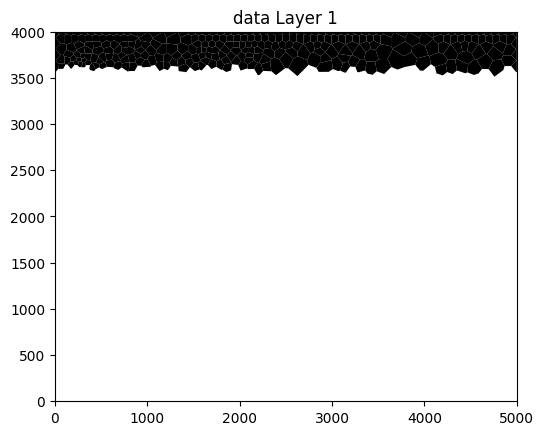

In [31]:
import flopy

flopy.plot.PlotUtilities._plot_bc_helper(package=model.gwf.drn, kper=0)

In [39]:
model.outputs.uzf.ifno_to_cellid

,layer,cellid
ifno,,
0,0,0
1,0,1
2,0,2
3,0,3
4,0,4
...,...,...
4973,0,4973
4974,0,4974
4975,0,4975
